<a href="https://colab.research.google.com/github/DianaBravoPerez/EDP-1/blob/main/poisson_generacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Poisson


La distribución de Poisson sirve para contar cuántas veces ocurre algo
en un intervalo fijo de tiempo o espacio. Por ejemplo: cuántos clientes
llegan a una tienda en una hora, o cuántos autos pasan por una caseta
en 10 minutos.

El único parámetro que necesita es $\lambda > 0$, que representa el
promedio de ocurrencias en ese intervalo.

Una variable aleatoria $X$ es Poisson con media $\lambda$ si:

$$P\{X = i\} = e^{-\lambda} \frac{\lambda^i}{i!}, \quad i = 0, 1, 2, \ldots$$

Sus propiedades principales son que la media y la varianza son iguales
al parámetro $\lambda$:

$$E[X] = \lambda, \qquad \text{Var}(X) = \lambda$$

---

## Método de Generación

Para simular $X \sim \text{Poisson}(\lambda)$ usamos el algoritmo de Ross,
que se basa en la identidad:

$$p_{i+1} = \frac{\lambda}{i+1}\, p_i, \quad i \geq 0$$

Esto nos permite calcular cada probabilidad $p_i$ a partir de la anterior,
sin tener que evaluar $e^{-\lambda}\lambda^i/i!$ desde cero en cada paso.

### Pseudocódigo

1. Generar $R \sim U(0,1)$
2. $i = 0,\quad p = e^{-\lambda},\quad F = p$
3. Si $R < F$: hacer $X = i$ y terminar
4. $p = \dfrac{\lambda\, p}{i+1},\quad F = F + p,\quad i = i + 1$
5. Ir al paso 3

In [1]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

## Implementación del algoritmo

In [2]:
def generar_poisson(lam):
    """Genera una variable aleatoria Poisson(lam) usando el algoritmo de Ross."""
    R = random.random()        # Paso 1: generar R ~ U(0,1)
    i = 0
    p = math.exp(-lam)         # Paso 2: p = e^{-lambda}
    F = p                      #         F = p  (F acumula la CDF)
    while True:
        if R < F:              # Paso 3: si R < F, regresar X = i
            return i
        p = (lam / (i + 1)) * p   # Paso 4: actualizar p con la recurrencia
        F = F + p                  #         acumular en F
        i = i + 1                  #         siguiente valor

## Simulación y verificación

In [3]:
# Parámetros
lam = 4       # media de la distribución
n   = 10000   # número de muestras

# Generar muestras
muestras = [generar_poisson(lam) for _ in range(n)]

# Estadísticas muestrales
media_muestral    = np.mean(muestras)
varianza_muestral = np.var(muestras)

print(f"lambda (teórico):    {lam}")
print(f"Media muestral:      {media_muestral:.4f}")
print(f"Varianza muestral:   {varianza_muestral:.4f}")

lambda (teórico):    4
Media muestral:      4.0007
Varianza muestral:   4.0555


## Comparación: frecuencias simuladas vs. probabilidades teóricas

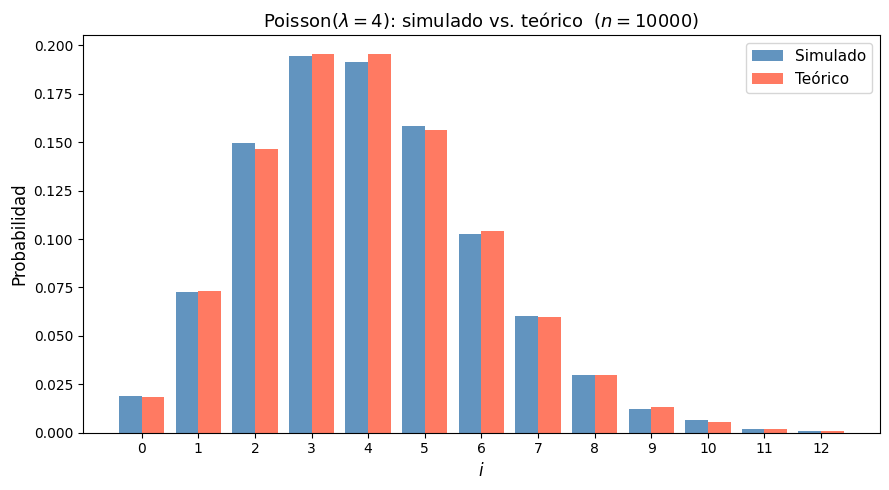

In [4]:
# Rango de valores a graficar
vals = np.arange(0, int(lam * 3) + 1)

# Frecuencias relativas simuladas
freq_sim = np.array([muestras.count(k) / n for k in vals])

# Probabilidades teóricas P{X = k}
prob_teo = np.array([math.exp(-lam) * lam**k / math.factorial(k) for k in vals])

# Gráfica
ancho = 0.4
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(vals - ancho/2, freq_sim, width=ancho, label='Simulado',  color='steelblue', alpha=0.85)
ax.bar(vals + ancho/2, prob_teo, width=ancho, label='Teórico',   color='tomato',    alpha=0.85)

ax.set_xlabel('$i$', fontsize=12)
ax.set_ylabel('Probabilidad', fontsize=12)
ax.set_title(f'Poisson($\\lambda={lam}$): simulado vs. teórico  ($n={n}$)', fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks(vals)
plt.tight_layout()
plt.show()